<a href="https://colab.research.google.com/github/noruzzaman-rahat/Research-With-Machine-Learning/blob/main/8_Introduction_to_Machine_Learning_Skill_Morph_updated_batch2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment <a id='11'></a>

**Dataset:** [Obesity Prediction Dataset](https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset) — Kaggle, February 2025

**File:** `obesity_prediction.csv` (~2,111 records, 17 columns)

**Features:** `Gender`, `Age`, `Height`, `Weight`, `family_history_with_overweight`, `FAVC` (high caloric food), `FCVC` (vegetable consumption), `NCP` (main meals), `CAEC` (food between meals), `SMOKE`, `CH2O` (water intake), `SCC` (calorie monitoring), `FAF` (physical activity), `TUE` (technology use), `CALC` (alcohol), `MTRANS` (transportation)

**Target:** `NObeyesdad` — Obesity level (7 classes)

---

### Question 1: Find the Best Tree Depth
Test `max_depth` values of 2, 3, 4, 5, 6, 7 on the Obesity dataset. Report accuracy for each and identify the optimal depth.

### Question 2: Calculate All Metrics
Using the best depth from Q1, compute Accuracy, Precision (weighted), Recall (weighted), and F1-Score (weighted). Display the classification report.

### Question 3: Feature Importance
Extract and plot the top 10 most important features from the best Decision Tree. Which lifestyle factors matter most for predicting obesity?

### Question 4: Confusion Matrix Analysis
Plot the confusion matrix (7×7) for the best model. Which obesity classes are most often confused with each other?

---
*Md. Samiul Islam, Instructor, Skill Morph Research Lab*

In [22]:
# 1. Import Libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
import warnings; warnings.filterwarnings('ignore')
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [23]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/skill morph/ObesityDataSet_raw_and_data_sinthetic.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
print(f"Missing: {data.isnull().sum().sum()}")
print(f"\n Target Distribution:\n{data['NObeyesdad'].value_counts()}")

Missing: 0

 Target Distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [41]:
# Question 1: Find the Best Tree Depth
# =========================================================

depths = [2, 3, 4, 5, 6, 7]

accuracy_results = {}

print("\n===== Accuracy for Different Tree Depths =====\n")

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy_results[depth] = acc

    print(f"Max Depth = {depth} ---> Accuracy = {acc:.4f}")

# Best Depth
best_depth = max(accuracy_results, key=accuracy_results.get)

print("\n===================================")
print(f"Best Tree Depth = {best_depth}")
print(f"Best Accuracy   = {accuracy_results[best_depth]:.4f}")
print("===================================")

# =========================================================
# Train Best Model
# =========================================================

best_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)


===== Accuracy for Different Tree Depths =====

Max Depth = 2 ---> Accuracy = 0.5366
Max Depth = 3 ---> Accuracy = 0.6147
Max Depth = 4 ---> Accuracy = 0.7447
Max Depth = 5 ---> Accuracy = 0.7967
Max Depth = 6 ---> Accuracy = 0.8794
Max Depth = 7 ---> Accuracy = 0.8960

Best Tree Depth = 7
Best Accuracy   = 0.8960


In [32]:
# Question 2: Calculate All Metrics
# =========================================================

# 5. Train-Test Split <a id='5'></a>
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
print(f"📚 Training: {X_train.shape} | 🧪 Testing: {X_test.shape}")

📚 Training: (1688, 23) | 🧪 Testing: (423, 23)



========== Top 10 Important Features ==========

            Feature  Importance
2            Weight    0.500723
1            Height    0.259448
8       Gender_Male    0.174542
10         FAVC_yes    0.019339
0               Age    0.012792
3              FCVC    0.010155
11  CAEC_Frequently    0.006022
4               NCP    0.005061
5              CH2O    0.003387
6               FAF    0.003351


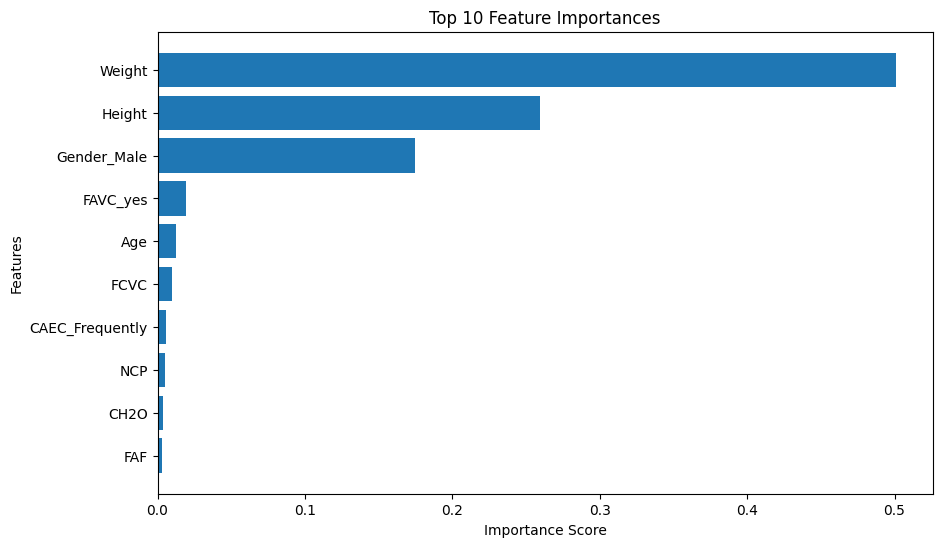

In [42]:
# Question 3: Feature Importance
# =========================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

# Sort Features
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 Features
top10 = feature_importance.head(10)

print("\n========== Top 10 Important Features ==========\n")
print(top10)

# Plot Feature Importance
plt.figure(figsize=(10, 6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()

plt.show()

In [46]:
#  Train the Decision Tree
model = DecisionTreeClassifier(max_depth=5, random_state=20)
model.fit(X_train, y_train)
print("✅ Model training complete!")

✅ Model training complete!


In [45]:
#  Predictions & Accuracy
predictions = model.predict(X_test)
prediction_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, predictions)
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

🎯 Accuracy: 0.8960 (89.60%)


<Figure size 1000x800 with 0 Axes>

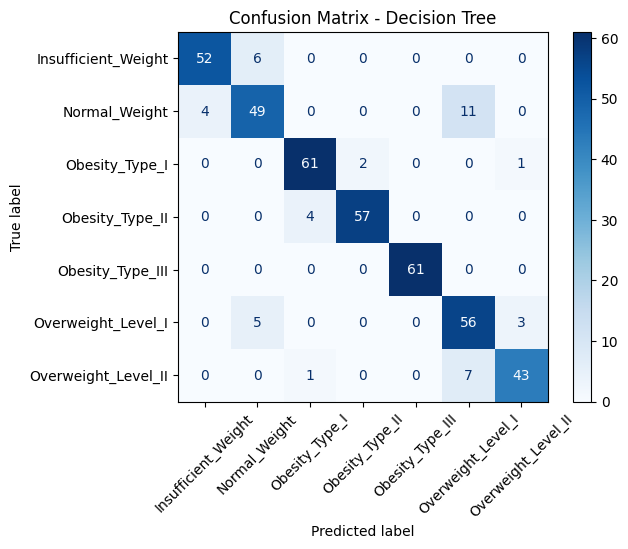


========== Confusion Matrix ==========

[[52  6  0  0  0  0  0]
 [ 4 49  0  0  0 11  0]
 [ 0  0 61  2  0  0  1]
 [ 0  0  4 57  0  0  0]
 [ 0  0  0  0 61  0  0]
 [ 0  5  0  0  0 56  3]
 [ 0  0  1  0  0  7 43]]

Most confusion generally occurs between
neighboring obesity levels such as:
- Overweight Level I vs Overweight Level II
- Obesity Type I vs Obesity Type II
- Normal Weight vs Overweight Level I


In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

# Question 4: Confusion Matrix Analysis
# =========================================================

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))

target_names = label_encoders['NObeyesdad'].classes_

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix - Decision Tree")
plt.show()

# =========================================================
# Extra Analysis
# =========================================================

print("\n========== Confusion Matrix ==========\n")
print(cm)

print("\nMost confusion generally occurs between")
print("neighboring obesity levels such as:")
print("- Overweight Level I vs Overweight Level II")
print("- Obesity Type I vs Obesity Type II")
print("- Normal Weight vs Overweight Level I")

In [49]:
# Performance Scores
accuracy  = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='weighted')
recall    = recall_score(y_test, predictions, average='weighted')
f1        = f1_score(y_test, predictions, average='weighted')

print(f"Accuracy : {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

Accuracy : 0.8960 | Precision: 0.8991 | Recall: 0.8960 | F1: 0.8965


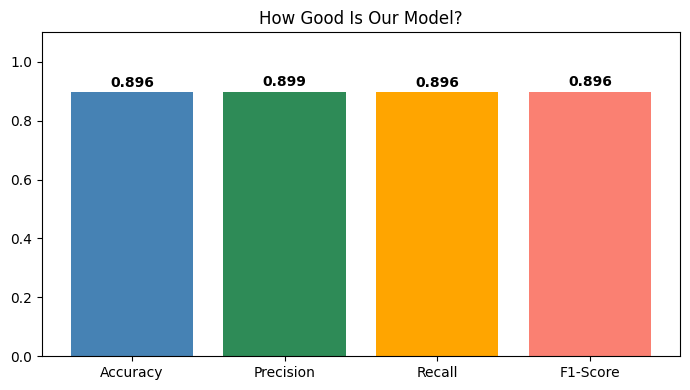

In [50]:
# Visual comparison
fig, ax = plt.subplots(figsize=(7, 4))
names, vals = ['Accuracy', 'Precision', 'Recall', 'F1-Score'], [accuracy, precision, recall, f1]
bars = ax.bar(names, vals, color=['steelblue', 'seagreen', 'orange', 'salmon'])
ax.set_ylim(0, 1.1); ax.set_title('How Good Is Our Model?')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. ROC Curve & AUC Score <a id='10'></a>

The **ROC Curve** shows how well the model separates the two classes across *all possible thresholds*.

- **AUC = 1.0** → Perfect model
- **AUC = 0.5** → Random guessing (useless)
- **AUC > 0.9** → Excellent

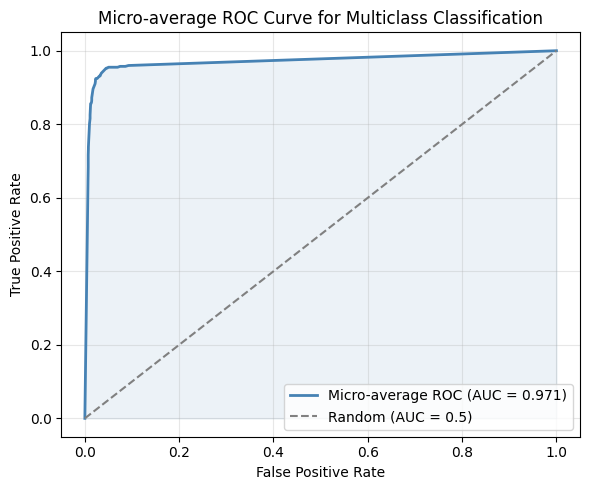

Micro-average AUC: 0.9714


In [53]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

#  ROC Curve & AUC
# Recalculate prediction_proba using best_model for consistency and all classes
prediction_proba_all_classes = best_model.predict_proba(X_test)

# Binarize y_test for multiclass ROC calculation
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)

# Calculate micro-average ROC curve and AUC
# This treats each element of the label indicator matrix as a binary prediction task
fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), prediction_proba_all_classes.ravel())
auc_micro = roc_auc_score(y_test, prediction_proba_all_classes, multi_class='ovr', average='micro')

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'Micro-average ROC (AUC = {auc_micro:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC Curve for Multiclass Classification')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Micro-average AUC: {auc_micro:.4f}")